In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/Food_Delivery_Orders_PowerBI_Activity - Food_Delivery_Orders_PowerBI_Activity.csv')
df.head()

,Order_ID,Customer_ID,Order_Date,City,Area,Food_Category,Restaurant_Type,Payment_Method,Order_Amount,Delivery_Minutes,Rating,Promo_Used
0,ORD00001,CUST0001,2026-05-03,Karachi,Gulshan-e-Iqbal,Chinese,Fast Food,Card,1420,55,3,No
1,ORD00002,CUST0002,2026-05-02,Karachi,Clifton,Chinese,Casual Dining,Card,1880,51,3,No
2,ORD00003,CUST0003,2026-05-08,Lahore,Wapda Town,Healthy,Casual Dining,Cash,1090,55,1,No
3,ORD00004,CUST0004,2026-05-26,Islamabad,Blue Area,Burgers,Cloud Kitchen,Card,1050,36,4,Yes
4,ORD00005,CUST0005,2026-05-14,Lahore,Johar Town,Desi,Casual Dining,Card,1180,20,5,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order_ID          1200 non-null   object
 1   Customer_ID       1200 non-null   object
 2   Order_Date        1200 non-null   object
 3   City              1200 non-null   object
 4   Area              1200 non-null   object
 5   Food_Category     1200 non-null   object
 6   Restaurant_Type   1200 non-null   object
 7   Payment_Method    1200 non-null   object
 8   Order_Amount      1200 non-null   int64 
 9   Delivery_Minutes  1200 non-null   int64 
 10  Rating            1200 non-null   int64 
 11  Promo_Used        1200 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.6+ KB


In [ ]:
df.describe()

,Order_Amount,Delivery_Minutes,Rating
count,1200.000000,1200.000000,1200.000000
mean,1144.216667,38.906667,3.846667
std,484.731737,13.207763,0.943697
min,300.000000,18.000000,1.000000
25%,760.000000,29.000000,3.000000
50%,1110.000000,37.000000,4.000000
75%,1470.000000,45.000000,5.000000
max,2490.000000,76.000000,5.000000


In [ ]:
df.dtypes

,0
Order_ID,object
Customer_ID,object
Order_Date,object
City,object
Area,object
Food_Category,object
Restaurant_Type,object
Payment_Method,object
Order_Amount,int64
Delivery_Minutes,int64


In [ ]:
display(df.isnull().sum())
print()
print("="*25)
print()
print(df.duplicated().sum())

,0
Order_ID,0
Customer_ID,0
Order_Date,0
City,0
Area,0
Food_Category,0
Restaurant_Type,0
Payment_Method,0
Order_Amount,0
Delivery_Minutes,0




0


In [ ]:
df['Payment_Method'].value_counts()
df['Payment_Method'].replace(
    ['CARD','E-Wallet','cash'],
    ['Card','Wallet','Cash'],
    inplace=True
)
df['Payment_Method'].value_counts()

/tmp/ipykernel_2042/295170605.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment_Method'].replace(


,count
Payment_Method,
Cash,534
Card,397
Wallet,269


In [ ]:
def delivery_speed(time):
    if time <= 30:
        return "Fast"
    elif time == 45 & time > 30:
        return "Normal"
    else:
        return "Delayed"

df["Delivery Speed"] = df["Delivery_Minutes"].apply(delivery_speed)
df.head()

,Order_ID,Customer_ID,Order_Date,City,Area,Food_Category,Restaurant_Type,Payment_Method,Order_Amount,Delivery_Minutes,Rating,Promo_Used,Delivery Speed
0,ORD00001,CUST0001,2026-05-03,Karachi,Gulshan-e-Iqbal,Chinese,Fast Food,Card,1420,55,3,No,Delayed
1,ORD00002,CUST0002,2026-05-02,Karachi,Clifton,Chinese,Casual Dining,Card,1880,51,3,No,Delayed
2,ORD00003,CUST0003,2026-05-08,Lahore,Wapda Town,Healthy,Casual Dining,Cash,1090,55,1,No,Delayed
3,ORD00004,CUST0004,2026-05-26,Islamabad,Blue Area,Burgers,Cloud Kitchen,Card,1050,36,4,Yes,Normal
4,ORD00005,CUST0005,2026-05-14,Lahore,Johar Town,Desi,Casual Dining,Card,1180,20,5,No,Fast


In [ ]:
print("Total oOrders in Dataset: ",df['Order_ID'].value_counts().sum())
print()
print("No. of customers: ",df['Customer_ID'].nunique())
print()
print("Average delivery time: ",df['Delivery_Minutes'].mean().round(2))


Total oOrders in Dataset:  1200

No. of customers:  420

Average delivery time:  38.91


,Area,Order_Amount
11,Gulshan-e-Iqbal,164300
5,DHA,122700
15,North Nazimabad,113010
4,Clifton,101570
16,PECHS,99440


/tmp/ipykernel_2042/992318943.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x=top_5_areas['Area'],y=top_5_areas['Order_Amount'],palette='viridis')


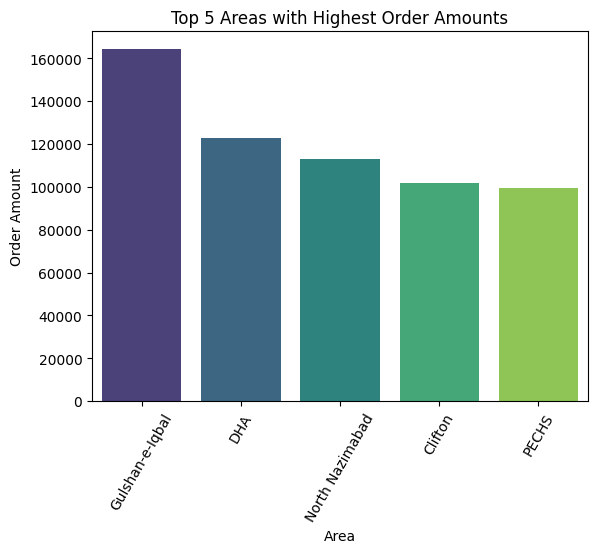

In [ ]:
top_5_areas = df.groupby("Area")["Order_Amount"].sum().reset_index().sort_values(by="Order_Amount", ascending=False).head(5)
display(top_5_areas)
print()
sns.barplot(data=df,x=top_5_areas['Area'],y=top_5_areas['Order_Amount'],palette='viridis')
plt.xlabel('Area')
plt.ylabel('Order Amount')
plt.title('Top 5 Areas with Highest Order Amounts')
plt.xticks(rotation=60)
plt.show()

,Food_Category,Order_Amount
4,Desi,346500
6,Pizza,310000
3,Chinese,262700
2,Burgers,209720
5,Healthy,99300
1,Beverages,74680
0,Bakery,70160


/tmp/ipykernel_2042/4211496293.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x=categories_by_orders['Food_Category'],y=categories_by_orders['Order_Amount'],palette='viridis')


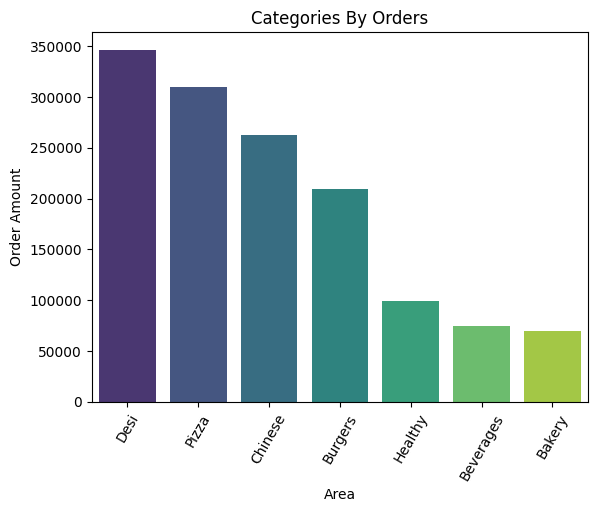

In [ ]:
categories_by_orders= df.groupby("Food_Category")["Order_Amount"].sum().reset_index().sort_values(by="Order_Amount", ascending=False)
display(categories_by_orders)
print()
sns.barplot(data=df,x=categories_by_orders['Food_Category'],y=categories_by_orders['Order_Amount'],palette='viridis')
plt.xlabel('Area')
plt.ylabel('Order Amount')
plt.title('Categories By Orders')
plt.xticks(rotation=60)
plt.show()

<Axes: xlabel='Promo_Used', ylabel='count'>

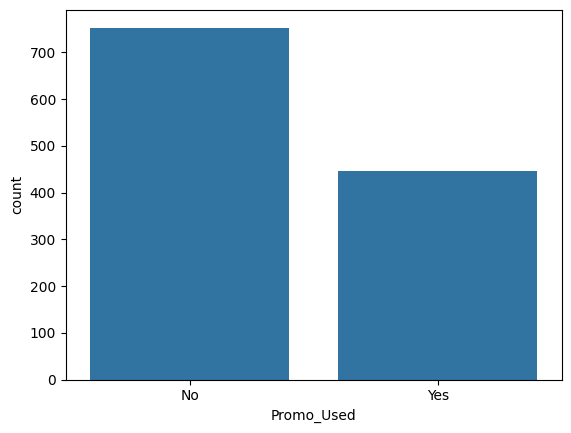

In [ ]:
sns.countplot(data=df,x=df['Promo_Used'])

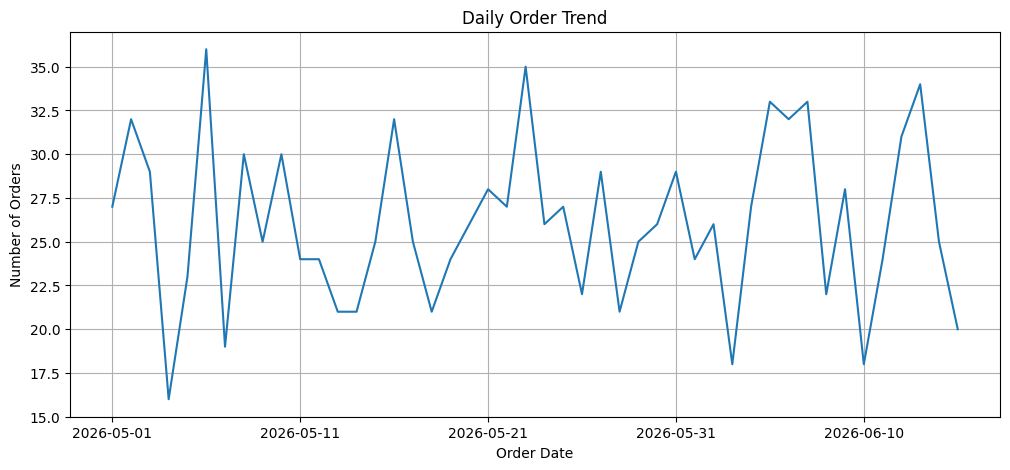

In [ ]:
daily_orders = df.groupby("Order_Date")["Order_ID"].count()
daily_orders.plot(kind="line", figsize=(12,5))
plt.grid()
plt.xlabel("Order Date")
plt.ylabel("Number of Orders")
plt.title("Daily Order Trend")
plt.show()

/tmp/ipykernel_2042/894970837.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x=df['Delivery Speed'],palette='viridis')


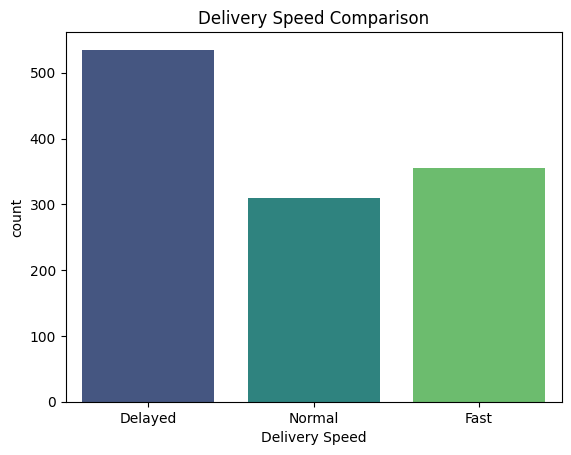

In [ ]:
sns.countplot(data=df,x=df['Delivery Speed'],palette='viridis')
#plt.xlabel('Area')
#plt.ylabel('Order Amount')
plt.title('Delivery Speed Comparison')
plt.show()

In [ ]:
df.to_csv("cleaned_delivery_orders.csv",index=False)